# Cluster Definition and Back-Projection

For a given CBSA:
1. Load the 2020 dual graph; find the 2 largest connected components of majority-Black tracts
2. Visualize them by centroid scatter and polygon choropleth
3. Back-project both clusters to 1980–2010 via areal overlap (>50% of each earlier-year tract)
4. Check graph connectivity of the back-projected tracts in the earlier-year dual graphs
5. Save all-years cluster membership to CSV in the `manual_cluster_tracts.csv` format

In [161]:
import json
from pathlib import Path
from shapely.ops import unary_union
from shapely.geometry import Polygon
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CBSA = "1245000"  # "1714000" = Chicago, "4260000" = Philly, "1245000" = Miami

OVERLAP_THRESHOLD = 0.50
YEARS = [1980, 1990, 2000, 2010, 2020]

ROOT = Path("/Users/maria/Documents/capy-bara")
DUAL_GRAPHS_DIR = ROOT / "data" / "processed" / "dual_graphs"
CLIPPED_GEO_DIR = ROOT / "data" / "processed" / "clipped_geographies"
OUTPUT_FILE = ROOT / "experiments" / "h4_t3_observed_diffusion" / "data" / "auto_cluster_tracts.csv"

COLORS = {"cluster_1": "steelblue", "cluster_2": "tomato"}


def compute_threshold(G):
    """Black share of the whole graph: total BLACK / (total BLACK + total WHITE)."""
    total_black = sum(int(attrs["BLACK"]) for _, attrs in G.nodes(data=True))
    total_white = sum(int(attrs["WHITE"]) for _, attrs in G.nodes(data=True))
    return total_black / (total_black + total_white)

## Step 1 — 2020 dual graph: define majority-Black clusters

In [162]:
# graph_file = DUAL_GRAPHS_DIR / "2020" / f"tracts_in_max_city_{CBSA}_2020_march_2020_vintage_connected.json"
graph_file = DUAL_GRAPHS_DIR / "2020" / f"tracts_in_max_city_{CBSA}_2020_march_2020_vintage_orig.json"

with open(graph_file) as f:
    graph_data = json.load(f)

G_2020 = nx.Graph()
for node in graph_data["nodes"]:
    G_2020.add_node(node["id"], **node)
for node_id, neighbors in enumerate(graph_data["adjacency"]):
    for edge in neighbors:
        G_2020.add_edge(node_id, edge["id"], shared_perim=edge["shared_perim"])

zero_pop = [n for n in G_2020.nodes()
            if int(G_2020.nodes[n].get("BLACK", 0)) + int(G_2020.nodes[n].get("WHITE", 0)) == 0]
G_2020.remove_nodes_from(zero_pop)
print(f"2020 graph: {G_2020.number_of_nodes()} nodes, {G_2020.number_of_edges()} edges "
      f"({len(zero_pop)} zero-pop nodes removed)")

BLACK_SHARE_THRESHOLD = compute_threshold(G_2020)
print(f"Computed threshold: {BLACK_SHARE_THRESHOLD:.1%}")

2020 graph: 129 nodes, 308 edges (0 zero-pop nodes removed)
Computed threshold: 46.0%


In [163]:
nodes_df = pd.DataFrame([G_2020.nodes[n] for n in G_2020.nodes()])
nodes_df["black_share"] = nodes_df["BLACK"] / (nodes_df["BLACK"] + nodes_df["WHITE"]).replace(0, pd.NA) #nodes_df["TOTPOP"].replace(0, pd.NA) # or out of White + Black?
nodes_df["majority_black"] = nodes_df["black_share"] > BLACK_SHARE_THRESHOLD

print(f"Total tracts: {len(nodes_df)}")
print(f"Majority-Black (>{BLACK_SHARE_THRESHOLD:.0%}): {nodes_df['majority_black'].sum()}")
print(f"Below threshold: {(~nodes_df['majority_black']).sum()}")

Total tracts: 129
Majority-Black (>46%): 32
Below threshold: 97


In [164]:
majority_ids = set(nodes_df.loc[nodes_df["majority_black"], "id"])
G_black = G_2020.subgraph(majority_ids)

components = sorted(nx.connected_components(G_black), key=len, reverse=True)
print(f"Connected components in majority-Black subgraph: {len(components)}")
print(f"Sizes of top 5: {[len(c) for c in components[:5]]}")

cluster_node_ids = {"cluster_1": components[0], "cluster_2": components[1]}
for label, ids in cluster_node_ids.items():
    print(f"  {label}: {len(ids)} tracts")

Connected components in majority-Black subgraph: 4
Sizes of top 5: [28, 2, 1, 1]
  cluster_1: 28 tracts
  cluster_2: 2 tracts


In [128]:
components[5]

{449, 472}

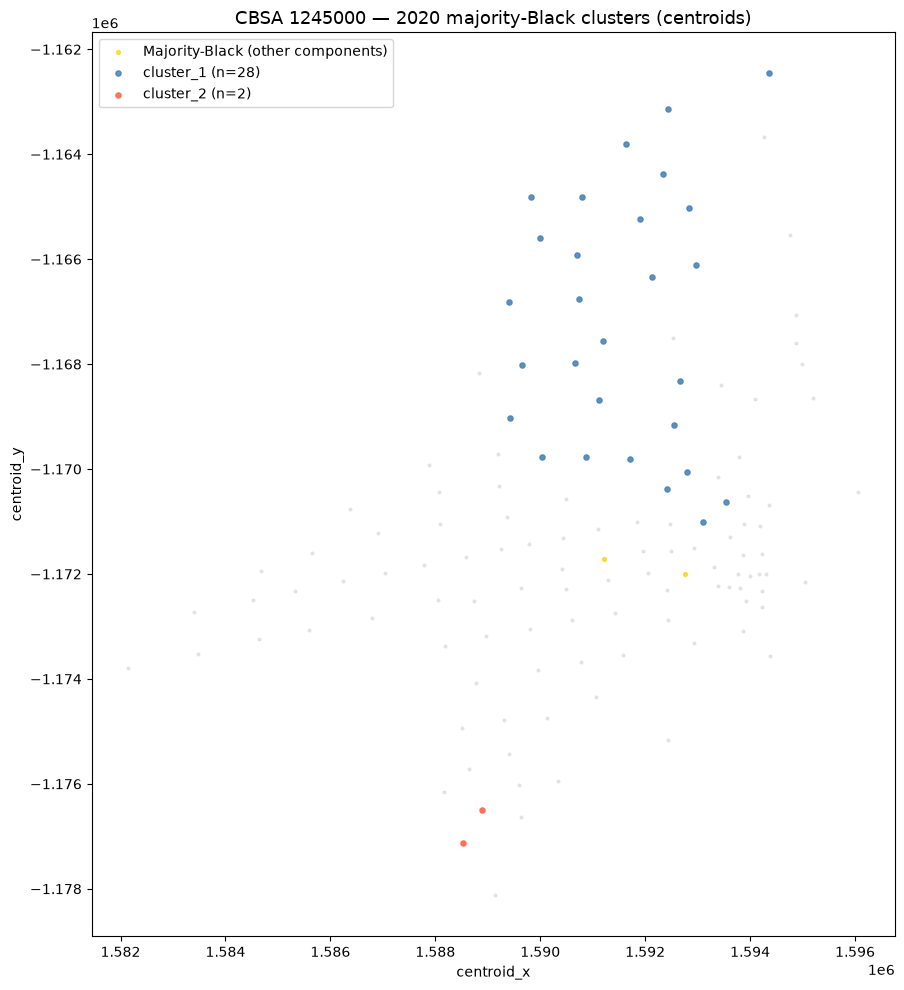

In [165]:
other_black_ids = majority_ids - cluster_node_ids["cluster_1"] - cluster_node_ids["cluster_2"]

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    nodes_df["centroid_x"], nodes_df["centroid_y"],
    s=4, color="lightgray", alpha=0.5, zorder=1
)
ax.scatter(
    nodes_df.loc[nodes_df["id"].isin(other_black_ids), "centroid_x"],
    nodes_df.loc[nodes_df["id"].isin(other_black_ids), "centroid_y"],
    s=8, color="gold", alpha=0.7, zorder=2, label="Majority-Black (other components)"
)
for label, ids in cluster_node_ids.items():
    sub = nodes_df[nodes_df["id"].isin(ids)]
    ax.scatter(
        sub["centroid_x"], sub["centroid_y"],
        s=14, color=COLORS[label], alpha=0.85, zorder=3,
        label=f"{label} (n={len(ids)})"
    )

ax.set_title(f"CBSA {CBSA} — 2020 majority-Black clusters (centroids)", fontsize=13)
ax.set_xlabel("centroid_x")
ax.set_ylabel("centroid_y")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Step 2 — Map graph nodes to 2020 polygon geometries

In [150]:
gpkg_2020 = CLIPPED_GEO_DIR / "2020" / f"tracts_in_max_city_{CBSA}_2020_march_2020_vintage.gpkg"
gdf_2020 = gpd.read_file(gpkg_2020)

# Map graph node ids → GEOIDs → gpkg rows
cluster_geoids = {label: set(nodes_df.loc[nodes_df["id"].isin(ids), "GEOID"])
    for label, ids in cluster_node_ids.items()}

cluster_gdfs_2020 = {}
for label, geoids in cluster_geoids.items():
    gdf = gdf_2020[gdf_2020["GEOID"].isin(geoids)].copy()
    gdf["cluster"] = label
    cluster_gdfs_2020[label] = gdf
    print(f"2020 {label}: {len(gdf)} tracts matched in gpkg (of {len(geoids)} graph nodes)")

2020 cluster_1: 28 tracts matched in gpkg (of 28 graph nodes)
2020 cluster_2: 2 tracts matched in gpkg (of 2 graph nodes)


In [151]:
#Fill Holes
from shapely.geometry import Polygon

cluster_shapes_2020 = {}

for label, gdf in cluster_gdfs_2020.items():
    dissolved = gdf.dissolve().geometry.iloc[0]
    dissolved = Polygon(dissolved.exterior)

    cluster_shapes_2020[label] = gpd.GeoDataFrame(geometry=[dissolved], crs=gdf.crs)

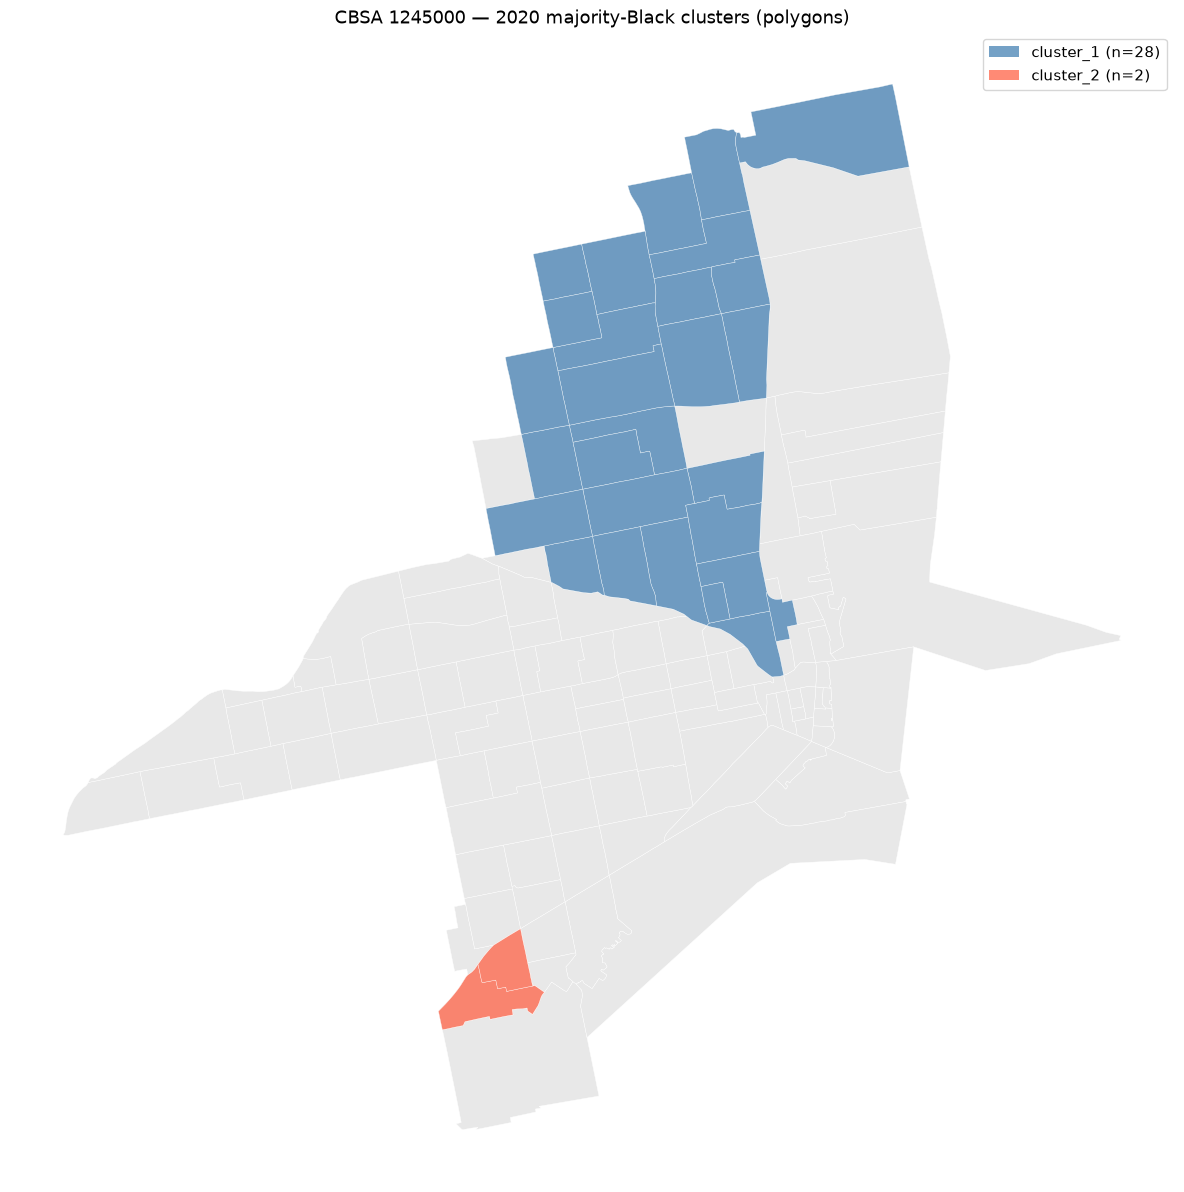

In [152]:
fig, ax = plt.subplots(figsize=(12, 12))
gdf_2020.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)
for label, gdf in cluster_gdfs_2020.items():
    gdf.plot(ax=ax, color=COLORS[label], alpha=0.75, edgecolor="white", linewidth=0.3)

legend_handles = [
    mpatches.Patch(facecolor=COLORS[lbl], alpha=0.75,
                   label=f"{lbl} (n={len(cluster_gdfs_2020[lbl])})")
    for lbl in ["cluster_1", "cluster_2"]]
ax.legend(handles=legend_handles, fontsize=11)
ax.set_title(f"CBSA {CBSA} — 2020 majority-Black clusters (polygons)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Step 3 — Back-project to 1980–2010 via areal overlap

For each earlier-year tract: if `intersection_area / tract_area > 0.50`, it belongs to the cluster.

In [153]:
def back_project_cluster(gdf_cluster_2020, gdf_target, overlap_threshold=0.50):
    """
    Returns rows of gdf_target whose tract area overlaps > overlap_threshold with the dissolved 2020 cluster polygon.
    """
    if gdf_target.crs != gdf_cluster_2020.crs:
        gdf_target = gdf_target.to_crs(gdf_cluster_2020.crs)

    cluster_union = unary_union(gdf_cluster_2020.geometry)

    target = gdf_target.copy()
    target["_tract_area"] = target.geometry.area
    target["_inter_area"] = target.geometry.intersection(cluster_union).area
    target["_overlap"] = target["_inter_area"] / target["_tract_area"]

    return (target[target["_overlap"] > overlap_threshold]
        .drop(columns=["_tract_area", "_inter_area", "_overlap"])
        .copy())

In [134]:
cluster_gdfs_2020['cluster_1'].head(3)

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,JOIN_KEY,GISJOIN,WHITE,BLACK,TOTPOP,POC,geometry,cluster
0,17,031,510300,17031510300,5103,Census Tract 5103,G5020,S,2958348,0,+41.7157373,-087.5749771,17031510300,G17031510300,16,4609,4850,4834,"MULTIPOLYGON (((693902.396 503898.044, 693940....",cluster_1
12,17,031,834800,17031834800,8348,Census Tract 8348,G5020,S,599866,0,+41.7836336,-087.6450883,17031834800,G17031834800,9,1554,1753,1744,"MULTIPOLYGON (((688145.288 510543.278, 688165....",cluster_1
13,17,031,834700,17031834700,8347,Census Tract 8347,G5020,S,657991,0,+41.7906903,-087.6450334,17031834700,G17031834700,11,1544,1759,1748,"MULTIPOLYGON (((688058.317 511353.773, 688071....",cluster_1


In [154]:
# cluster_yearly[year][cluster_label] → GeoDataFrame of matched tracts
cluster_yearly = {2020: cluster_gdfs_2020}

for year in YEARS:
    gpkg_path = CLIPPED_GEO_DIR / str(year) / f"tracts_in_max_city_{CBSA}_{year}_march_2020_vintage.gpkg"
    gdf_year = gpd.read_file(gpkg_path)
    cluster_yearly[year] = {}

    for label, gdf_cluster in cluster_shapes_2020.items():
        matched = back_project_cluster(gdf_cluster, gdf_year, OVERLAP_THRESHOLD)
        matched = matched.copy()
        matched["cluster"] = label
        cluster_yearly[year][label] = matched
        print(f"{year} {label}: {len(matched)} tracts")

1980 cluster_1: 18 tracts
1980 cluster_2: 1 tracts
1990 cluster_1: 23 tracts
1990 cluster_2: 1 tracts
2000 cluster_1: 24 tracts
2000 cluster_2: 1 tracts
2010 cluster_1: 27 tracts
2010 cluster_2: 2 tracts
2020 cluster_1: 28 tracts
2020 cluster_2: 2 tracts


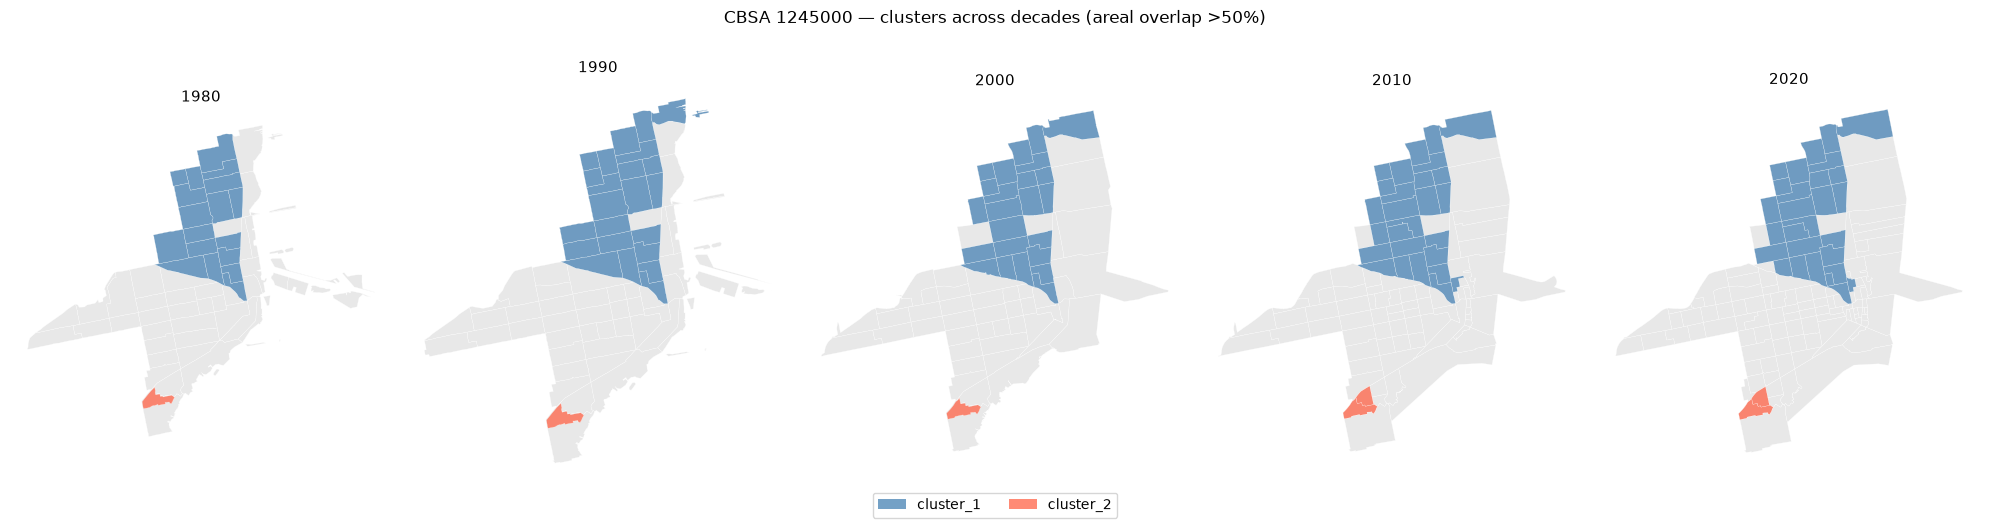

In [155]:
all_years = sorted(cluster_yearly.keys())
fig, axes = plt.subplots(1, len(all_years), figsize=(4 * len(all_years), 5))

for ax, year in zip(axes, all_years):
    gpkg_path = CLIPPED_GEO_DIR / str(year) / f"tracts_in_max_city_{CBSA}_{year}_march_2020_vintage.gpkg"
    base = gpd.read_file(gpkg_path)
    base.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.2)

    for label, gdf in cluster_yearly[year].items():
        if len(gdf) > 0:
            gdf.plot(ax=ax, color=COLORS[label], alpha=0.75, edgecolor="white", linewidth=0.2)

    ax.set_title(str(year), fontsize=11)
    ax.set_axis_off()

legend_handles = [
    mpatches.Patch(facecolor=COLORS[lbl], alpha=0.75, label=lbl)
    for lbl in ["cluster_1", "cluster_2"]
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"CBSA {CBSA} — clusters across decades (areal overlap >{OVERLAP_THRESHOLD:.0%})",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [137]:
base.head(4)
base["BLACK"] / (base["BLACK"] + base["WHITE"])

0      0.996541
1      0.453901
2      0.159898
3      0.043788
4      0.328377
         ...   
774    0.073333
775    0.996607
776    0.243876
777    0.511775
778    0.019214
Length: 779, dtype: float64

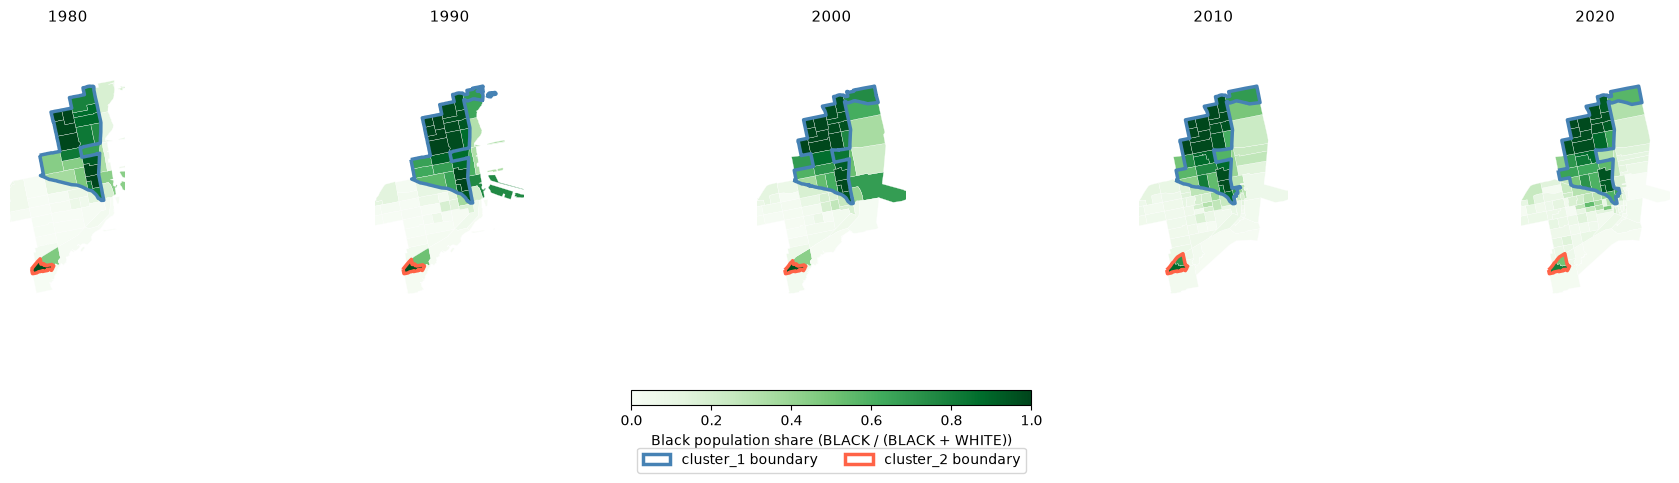

In [156]:
all_years = sorted(cluster_yearly.keys())
fig, axes = plt.subplots(1, len(all_years), figsize=(4 * len(all_years), 5))

cmap = "Greens"
vmin, vmax = 0, 1

for ax, year in zip(axes, all_years):
    gpkg_path = CLIPPED_GEO_DIR / str(year) / f"tracts_in_max_city_{CBSA}_{year}_march_2020_vintage.gpkg"
    base = gpd.read_file(gpkg_path)
    base["black_share"] = base["BLACK"] / (base["BLACK"] + base["WHITE"])

    base.plot(
        ax=ax, column="black_share", cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolor="white", linewidth=0.2,
        missing_kwds={"color": "lightgray", "edgecolor": "white", "linewidth": 0.2})

    cluster_gdfs_proj = []
    for label, gdf in cluster_yearly[year].items():
        if len(gdf) > 0:
            gdf_proj = gdf.to_crs(base.crs)
            gdf_proj.dissolve().boundary.plot(ax=ax, color=COLORS[label], linewidth=2.5, zorder=5)
            cluster_gdfs_proj.append(gdf_proj)

    minx, miny, maxx, maxy = pd.concat(cluster_gdfs_proj).total_bounds
    pad_x = (maxx - minx) * 0.3
    pad_y = (maxy - miny) * 0.3
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

    ax.set_title(str(year), fontsize=11)
    ax.set_axis_off()

# Reserve bottom 30% so colorbar and legend fit without overlapping
fig.tight_layout(rect=[0, 0.30, 1, 1])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
# Colorbar in the upper portion of the reserved strip
cbar_ax = fig.add_axes([0.40, 0.18, 0.20, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Black population share (BLACK / (BLACK + WHITE))", fontsize=10)

# Legend below the colorbar
legend_handles = [
    mpatches.Patch(facecolor="none", edgecolor=COLORS[lbl], linewidth=2.5,
                   label=f"{lbl} boundary")
    for lbl in ["cluster_1", "cluster_2"]]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 0.03))
plt.show()

## Step 4 — Graph connectivity check for earlier years

Load the earlier-year `_orig.json` dual graphs and check whether the areal-overlap-assigned
tracts form connected subgraphs.

**Why `_orig` not `_connected`**: the `_connected` files have a node id-position mismatch —
the `"id"` field doesn't equal the node's index in the adjacency list. The loading code uses
`enumerate()` for edge endpoints but `node["id"]` for `add_node()`, so `_connected` creates
phantom nodes and wrong edges. `_orig` files have zero mismatches in every year, so they
load correctly. This was also the root cause of the "disconnected-looking cluster_1" in the
scatter plot — with `_connected`, the wrong graph structure merged geographically separate
neighborhoods into one huge component.

In [157]:
def load_graph(json_path):
    """Load a dual-graph JSON into a networkx Graph, dropping zero-pop nodes. Returns (G, node_df)."""
    with open(json_path) as f:
        data = json.load(f)
    G = nx.Graph()
    for node in data["nodes"]:
        G.add_node(node["id"], **node)
    for node_id, neighbors in enumerate(data["adjacency"]):
        for edge in neighbors:
            G.add_edge(node_id, edge["id"], shared_perim=edge["shared_perim"])
    zero_pop = [n for n in G.nodes()
                if int(G.nodes[n].get("BLACK", 0)) + int(G.nodes[n].get("WHITE", 0)) == 0]
    G.remove_nodes_from(zero_pop)
    node_df = pd.DataFrame([attrs for _, attrs in G.nodes(data=True)])
    return G, node_df

In [140]:
gdf_matched.head(2)

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,JOIN_KEY,GISJOIN,WHITE,BLACK,TOTPOP,POC,geometry,cluster
0,42,101,012204,42101012204,122.04,Census Tract 122.04,G5020,S,879459,56473,+40.0009407,-075.2120769,42101012204,G42101012204,632,2587,3694,3062,"MULTIPOLYGON (((1744328.264 472098.32, 1744429...",cluster_2
9,42,101,002000,42101002000,20,Census Tract 20,G5020,S,290083,0,+39.9381467,-075.1843188,42101002000,G42101002000,880,1251,2537,1657,"MULTIPOLYGON (((1748583.122 465390.869, 174858...",cluster_2


In [158]:
connectivity_rows = []

for year in YEARS:
    json_path = DUAL_GRAPHS_DIR / str(year) / f"tracts_in_max_city_{CBSA}_{year}_march_2020_vintage_orig.json"
    G_year, node_df_year = load_graph(json_path)

    for label in ["cluster_1", "cluster_2"]:
        gdf_matched = cluster_yearly[year][label]
        if len(gdf_matched) == 0:
            continue

        matched_geoids = set(gdf_matched["GEOID"])
        matched_node_ids = set(
            node_df_year.loc[node_df_year["GEOID"].isin(matched_geoids), "id"])
        unmatched = matched_geoids - set(node_df_year["GEOID"])

        G_sub = G_year.subgraph(matched_node_ids)
        comps = sorted(nx.connected_components(G_sub), key=len, reverse=True)

        connectivity_rows.append({
            "year": year,
            "cluster": label,
            "areal_overlap_tracts": len(matched_geoids),
            "in_graph": len(matched_node_ids),
            "not_in_graph": len(unmatched),
            "n_components": len(comps),
            "largest_component": len(comps[0]) if comps else 0
        })

conn_df = pd.DataFrame(connectivity_rows)
print(conn_df.to_string(index=False))

 year   cluster  areal_overlap_tracts  in_graph  not_in_graph  n_components  largest_component
 1980 cluster_1                    18        18             0             1                 18
 1980 cluster_2                     1         1             0             1                  1
 1990 cluster_1                    23        23             0             1                 23
 1990 cluster_2                     1         1             0             1                  1
 2000 cluster_1                    24        24             0             1                 24
 2000 cluster_2                     1         1             0             1                  1
 2010 cluster_1                    27        27             0             1                 27
 2010 cluster_2                     2         2             0             1                  2
 2020 cluster_1                    28        28             0             1                 28
 2020 cluster_2                     2         2   

## Step 5 — Assemble and save output CSV

In [142]:
cluster_yearly[2020]#['cluster_2']
cluster_yearly[2000]['cluster_1'].head(2)

,STATEFP00,COUNTYFP00,TRACTCE00,CTIDFP00,NAME00,NAMELSAD00,MTFCC00,FUNCSTAT00,ALAND00,AWATER00,...,STATEFP,COUNTYFP,GEOID,GISJOIN,WHITE,BLACK,TOTPOP,POC,geometry,cluster
0,17,031,380600,17031380600,3806,Census Tract 3806,G5020,S,90262,0,...,17,031,17031380600,G17031380600,8,1073,1099,1091,"MULTIPOLYGON (((689831.839 513624.015, 689796....",cluster_1
1,17,031,380700,17031380700,3807,Census Tract 3807,G5020,S,244481,0,...,17,031,17031380700,G17031380700,18,1961,2006,1988,"MULTIPOLYGON (((690255.397 513444.213, 690228....",cluster_1


In [143]:
rows = []

for year, clusters in cluster_yearly.items():
    for label, gdf in clusters.items():
        if len(gdf) == 0:
            raise
        sub = gdf[["GEOID", "GISJOIN", "STATEFP", "COUNTYFP", "BLACK", "WHITE", "POC", "TOTPOP"]].copy()
        sub["cbsa"] = CBSA
        sub["year"] = year
        sub["cluster"] = label
        sub["black_share"] = sub["BLACK"] / (sub["BLACK"] + sub["WHITE"]).replace(0, pd.NA) #sub["TOTPOP"].replace(0, pd.NA)
        rows.append(sub)

df_out = (
    pd.concat(rows, ignore_index=True)
    .rename(columns={"BLACK": "black_population", "TOTPOP": "total_population",
                     "WHITE": "white_population", "POC": "poc_population",
                     "GEOID": "geoid", "GISJOIN": "gisjoin",
                     "STATEFP": "statefp", "COUNTYFP": "countyfp"})
    [["cbsa", "year", "cluster", "gisjoin", "geoid",
      "black_population", "total_population", "black_share"]]
    .sort_values(["cluster", "year", "geoid"])
    .reset_index(drop=True))

df_out.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(df_out)} rows to {OUTPUT_FILE}")
df_out.groupby(["year", "cluster"]).size().unstack("cluster")

Saved 1778 rows to /Users/maria/Documents/capy-bara/experiments/h4_t3_observed_diffusion/data/auto_cluster_tracts.csv


cluster,cluster_1,cluster_2
year,,
1980,260,121
1990,260,121
2000,260,121
2010,236,85
2020,230,84


In [144]:
GRAPH_OUT_DIR = ROOT / "experiments" / "h4_t3_observed_diffusion" / "data" / "cluster_graphs"
GRAPH_OUT_DIR.mkdir(parents=True, exist_ok=True)

CITY_NAMES = {"1714000": "chicago", "4260000": "philadelphia"}
KEEP_ATTRS = {"BLACK", "WHITE", "centroid_x", "centroid_y"}

city = CITY_NAMES[CBSA]

for year in sorted(cluster_yearly.keys()):
    json_path = DUAL_GRAPHS_DIR / str(year) / f"tracts_in_max_city_{CBSA}_{year}_march_2020_vintage_orig.json"
    G_year, node_df_year = load_graph(json_path)
    geoid_to_node = {attrs["GEOID"]: n for n, attrs in G_year.nodes(data=True)}

    for label, gdf in cluster_yearly[year].items():
        cluster_node_ids_year = {geoid_to_node[g] for g in gdf["GEOID"] if g in geoid_to_node}
        G_sub = G_year.subgraph(cluster_node_ids_year)

        node_order = list(G_sub.nodes())
        old_to_new = {old: new for new, old in enumerate(node_order)}

        nodes_out = [
            {"id": old_to_new[n], **{k: G_sub.nodes[n][k] for k in KEEP_ATTRS if k in G_sub.nodes[n]}}
            for n in node_order
        ]
        adjacency_out = [
            [{"id": old_to_new[nbr]} for nbr in G_sub.neighbors(n)]
            for n in node_order
        ]

        out_path = GRAPH_OUT_DIR / f"{city}_{year}_{label}.json"
        with open(out_path, "w") as f:
            json.dump({"nodes": nodes_out, "adjacency": adjacency_out}, f)
        print(f"Saved {out_path.name}  ({len(nodes_out)} nodes, {G_sub.number_of_edges()} edges)")

Saved chicago_1980_cluster_1.json  (259 nodes, 569 edges)
Saved chicago_1980_cluster_2.json  (119 nodes, 234 edges)
Saved chicago_1990_cluster_1.json  (259 nodes, 572 edges)
Saved chicago_1990_cluster_2.json  (119 nodes, 234 edges)
Saved chicago_2000_cluster_1.json  (259 nodes, 571 edges)
Saved chicago_2000_cluster_2.json  (120 nodes, 238 edges)
Saved chicago_2010_cluster_1.json  (234 nodes, 520 edges)
Saved chicago_2010_cluster_2.json  (85 nodes, 181 edges)
Saved chicago_2020_cluster_1.json  (230 nodes, 516 edges)
Saved chicago_2020_cluster_2.json  (84 nodes, 179 edges)


In [159]:
cluster_yearly.keys()

dict_keys([2020, 1980, 1990, 2000, 2010])

In [ ]:
# KEEP_ATTRS = {"BLACK", "WHITE", "centroid_x", "centroid_y"}
# GRAPH_OUT_DIR = ROOT / "experiments" / "h4_t3_observed_diffusion" / "data" / "cluster_graphs"
# GRAPH_OUT_DIR.mkdir(parents=True, exist_ok=True)

# for year in sorted(cluster_yearly.keys()):
#     json_path = DUAL_GRAPHS_DIR / str(year) / f"tracts_in_max_city_{CBSA}_{year}_march_2020_vintage_orig.json"
#     G_year, _ = load_graph(json_path)
#     geoid_to_node = {attrs["GEOID"]: n for n, attrs in G_year.nodes(data=True)}

#     gdf = cluster_yearly[year]["cluster_1"]
#     cluster_node_ids_year = {geoid_to_node[g] for g in gdf["GEOID"] if g in geoid_to_node}
#     G_sub = G_year.subgraph(cluster_node_ids_year)

#     node_order = list(G_sub.nodes())
#     old_to_new = {old: new for new, old in enumerate(node_order)}

#     nodes_out = [
#         {"id": old_to_new[n], **{k: G_sub.nodes[n][k] for k in KEEP_ATTRS if k in G_sub.nodes[n]}}
#         for n in node_order
#     ]
#     adjacency_out = [
#         [{"id": old_to_new[nbr]} for nbr in G_sub.neighbors(n)]
#         for n in node_order
#     ]

#     out_path = GRAPH_OUT_DIR / f"miami_{year}_cluster_1.json"
#     with open(out_path, "w") as f:
#         json.dump({"nodes": nodes_out, "adjacency": adjacency_out}, f)
#     print(f"Saved {out_path.name}  ({len(nodes_out)} nodes, {G_sub.number_of_edges()} edges)")

Saved miami_1980_cluster_1.json  (18 nodes, 31 edges)
Saved miami_1990_cluster_1.json  (23 nodes, 39 edges)
Saved miami_2000_cluster_1.json  (24 nodes, 40 edges)
Saved miami_2010_cluster_1.json  (27 nodes, 48 edges)
Saved miami_2020_cluster_1.json  (28 nodes, 51 edges)
